t‑SNE: нелинейное вложение, оптимизирует дивергенцию Кульбака–Лейблера между распределениями близостей точек, хорошо показывает локальные кластеры, но медленно, плохо сохраняет глобальные расстояния, чувствительно к perplexity и random_state.

UMAP: основан на теории многобразий и топологии, строит взвешенный граф соседей и оптимизирует кросс‑энтропию; быстрее t‑SNE, лучше сохраняет глобальную структуру, более устойчив к малым изменениям параметров (n_neighbors, min_dist).

TriMAP: ориентирован на сохранение глобальной структуры через тройки точек (anchor, сосед, далёкий), улучшает глобальное расположение кластеров при сохранении локальной структуры.

PaCMAP: управляет соотношением близких, средних и далёких пар, чтобы одновременно хорошо держать локальные кластеры и общую форму; показывает хорошие результаты на омикс‑данных и эмбеддингах.

PHATE: использует диффузионные процессы и потенциал для визуализации непрерывных траекторий (например, дифференцировка клеток), хорошо показывает как кластеры, так и переходы между ними.



In [15]:
%pip install umap-learn trimap pacmap phate scikit-learn seaborn

  Using cached trimap-1.1.5-py3-none-any.whl (15 kB)
  Using cached annoy-1.17.3.tar.gz (647 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Running setup.py install for annoy: started
  Running setup.py install for annoy: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  DEPRECATION: annoy is being installed using the legacy 'setup.py install' method, because it does not have a 'pyproject.toml' and the 'wheel' package is not installed. pip 23.1 will enforce this behaviour change. A possible replacement is to enable the '--use-pep517' option. Discussion can be found at https://github.com/pypa/pip/issues/8559
  error: subprocess-exited-with-error
  
  × Running setup.py install for annoy did not run successfully.
  │ exit code: 1
  ╰─> [35 lines of output]
      f:\Education\1course\2trim\Clasterization\venv\lib\site-packages\setuptools\__init__.py:94: _DeprecatedInstaller: setuptools.installer and fetch_build_eggs are deprecated.
      !!
      
              ********************************************************************************
              Requirements should be satisfied by a PEP 517 installer.
              If you are using pip, you can try `pip install --use-pep517`.
              *******************************************************

In [16]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import pairwise_distances
from sklearn.manifold import TSNE

import umap

try:
    import trimap
except ImportError:
    trimap = None

try:
    import pacmap
except ImportError:
    pacmap = None

try:
    import phate
except ImportError:
    phate = None


In [17]:
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
feature_names_iris = iris.feature_names
print(X_iris.shape, np.unique(y_iris))


(150, 4) [0 1 2]


In [18]:
path = Path("my_data.csv")
if path.exists():
    df = pd.read_csv(path)
else:
    df = pd.DataFrame(X_iris, columns=feature_names_iris)
    df["target"] = y_iris

df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [19]:
feature_cols = [c for c in df.columns if c != "target"]
X_own = df[feature_cols].values
y_own = df["target"].values
print(X_own.shape, len(np.unique(y_own)))


(150, 4) 3


In [20]:
scaler_iris = StandardScaler()
X_iris_scaled = scaler_iris.fit_transform(X_iris)
 


Функции для DR и оценки разделения

In [21]:
def run_tsne(X, random_state=42, perplexity=30, learning_rate=200, n_iter=1000):
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate=learning_rate,
        max_iter=n_iter,
        init="pca",
        random_state=random_state,
    )
    return tsne.fit_transform(X)

def run_umap(X, random_state=42, n_neighbors=15, min_dist=0.1):
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        random_state=random_state,
    )
    return reducer.fit_transform(X)

def run_trimap(X, random_state=42, n_inliers=10, n_outliers=5):
    if trimap is None:
        raise ImportError("trimap не установлен")
    reducer = trimap.TRIMAP(
        n_dims=2,
        n_inliers=n_inliers,
        n_outliers=n_outliers,
        random_state=random_state,
    )
    return reducer.fit_transform(X)

def run_pacmap(X, random_state=42, n_neighbors=10):
    if pacmap is None:
        raise ImportError("pacmap не установлен")
    reducer = pacmap.PaCMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        random_state=random_state,
    )
    return reducer.fit_transform(X)

def run_phate(X, random_state=42, knn=15):
    if phate is None:
        raise ImportError("phate не установлен")
    phate_op = phate.PHATE(
        n_components=2,
        knn=knn,
        random_state=random_state,
        verbose=0,
    )
    return phate_op.fit_transform(X)


Функция оценки качества разделения

In [22]:
def separation_score(X_2d, y):
    D = pairwise_distances(X_2d)
    same = D[y[:, None] == y[None, :]]
    diff = D[y[:, None] != y[None, :]]
    return same.mean(), diff.mean(), diff.mean() / same.mean()


In [23]:
def plot_embedding(X_2d, y, title):
    plt.figure(figsize=(6, 5))
    sns.scatterplot(
        x=X_2d[:, 0],
        y=X_2d[:, 1],
        hue=y,
        palette="tab10",
        s=30,
        legend="full"
    )
    plt.title(title)
    plt.xticks([])
    plt.yticks([])
    plt.legend(title="Класс", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


f:\Education\1course\2trim\Clasterization\venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


TriMAP: trimap не установлен


f:\Education\1course\2trim\Clasterization\venv\lib\site-packages\graphtools\graphs.py:803: RuntimeWarning: Detected zero distance between samples 101 and 142. Consider removing duplicates to avoid errors in downstream processing.
  warnings.warn(


    SGD-MDS may not have converged: stress changed by -1.4% in final iterations. Consider increasing n_iter or adjusting learning_rate.


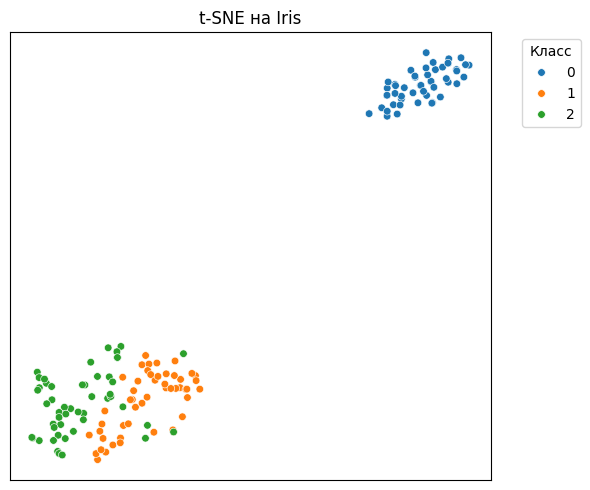

t-SNE: внутрикласс.=3.512, межкласс.=22.740, ratio=6.475


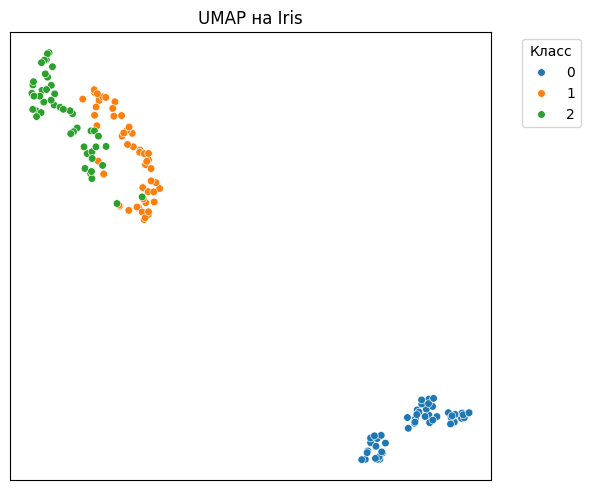

UMAP: внутрикласс.=1.862, межкласс.=11.935, ratio=6.411


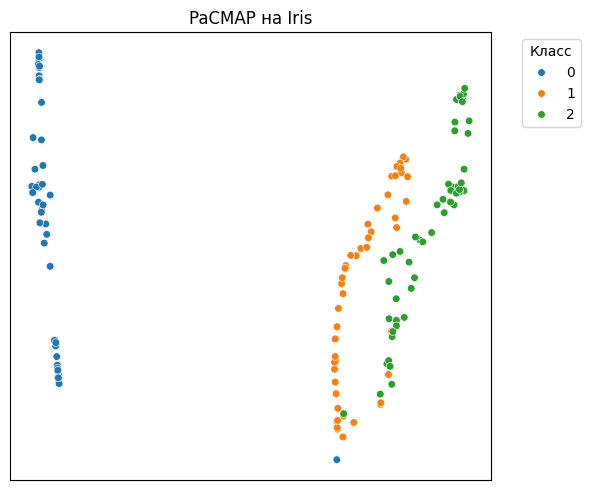

PaCMAP: внутрикласс.=3.470, межкласс.=17.674, ratio=5.093


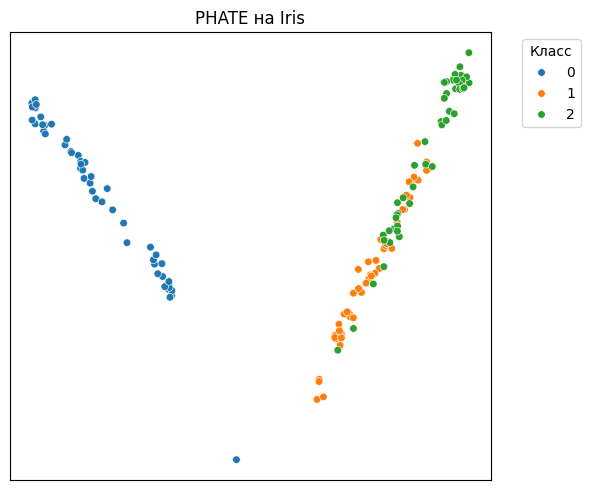

PHATE: внутрикласс.=0.026, межкласс.=0.121, ratio=4.610


In [24]:
methods = [
    ("t-SNE", run_tsne, {}),
    ("UMAP", run_umap, {}),
    ("TriMAP", run_trimap, {}),
    ("PaCMAP", run_pacmap, {}),
    ("PHATE", run_phate, {}),
]

X_list = []
names = []

for name, func, params in methods:
    try:
        X_emb = func(X_iris_scaled, random_state=42, **params)
        X_list.append(X_emb)
        names.append(name)
    except Exception as err:
        print(f"{name}: {err}")

for X_emb, name in zip(X_list, names):
    plot_embedding(X_emb, y_iris, f"{name} на Iris")
    same, diff, ratio = separation_score(X_emb, y_iris)
    print(
        f"{name}: внутрикласс.={same:.3f}, межкласс.={diff:.3f}, ratio={ratio:.3f}"
    )


Сравнение устойчивости

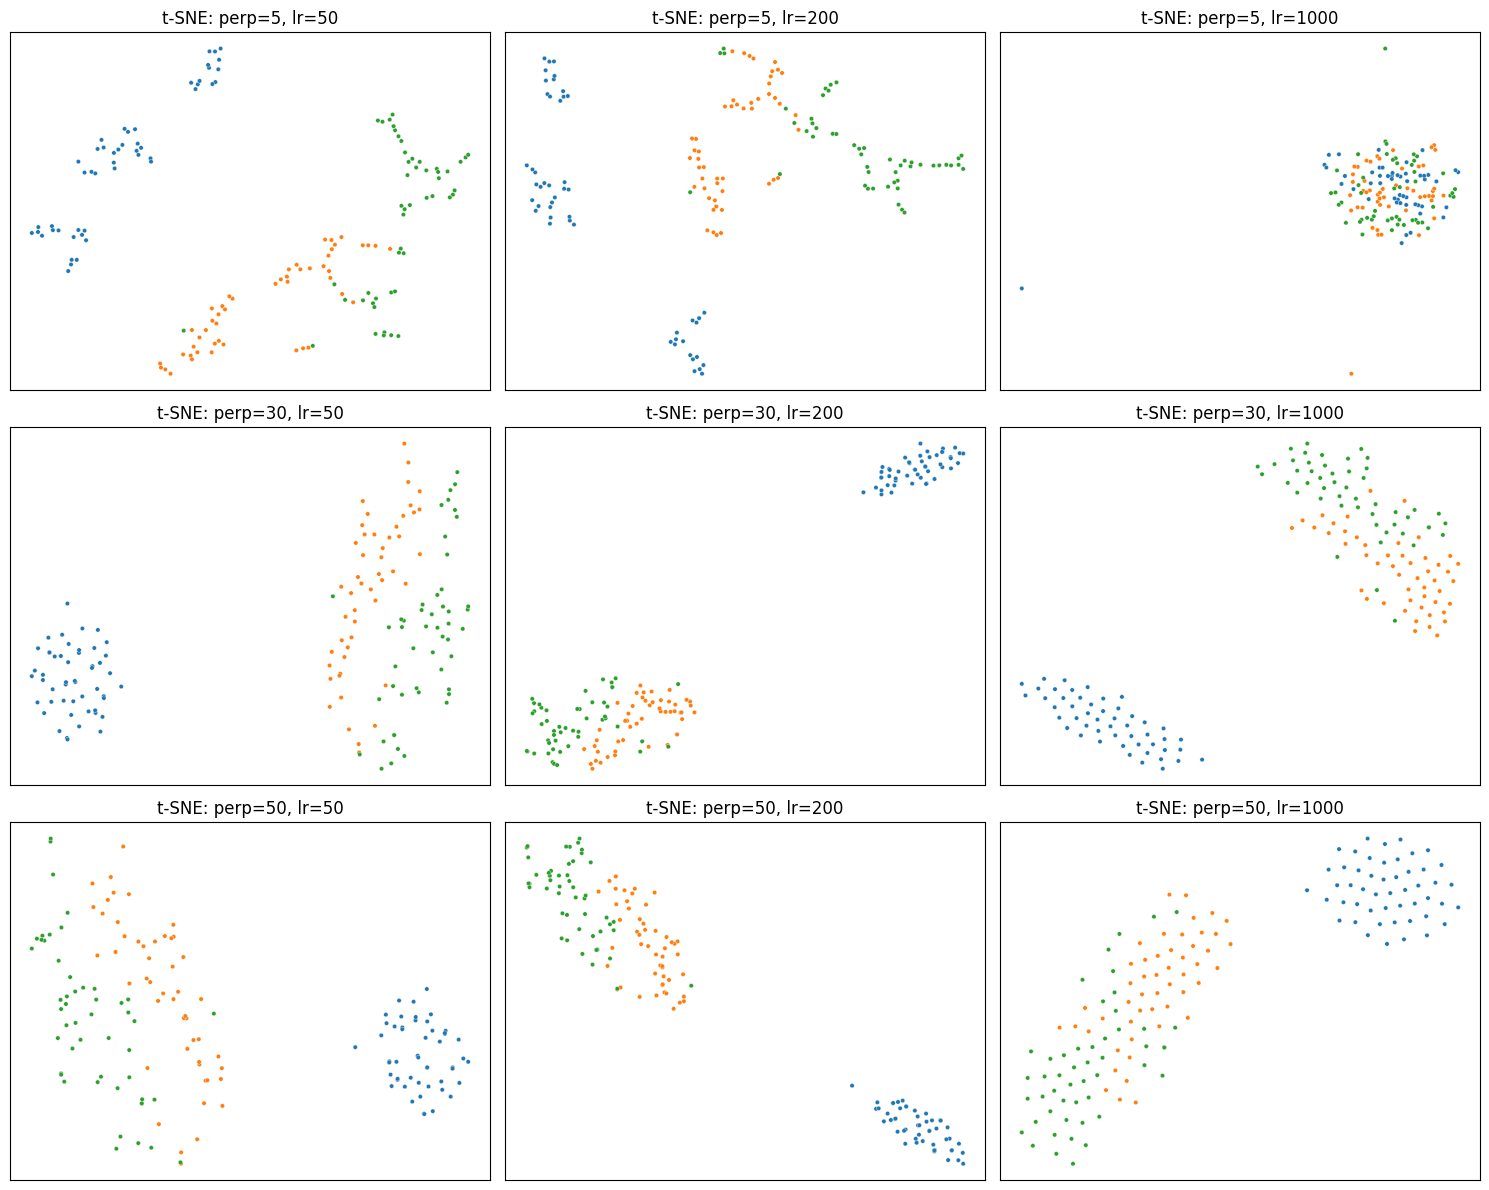

In [25]:
perplexities = [5, 30, 50]
lrs = [50, 200, 1000]

fig, axes = plt.subplots(len(perplexities), len(lrs), figsize=(5*len(lrs), 4*len(perplexities)))

for i, perp in enumerate(perplexities):
    for j, lr in enumerate(lrs):
        X_emb = run_tsne(X_iris_scaled, random_state=42, perplexity=perp, learning_rate=lr)
        ax = axes[i, j]
        sns.scatterplot(x=X_emb[:, 0], y=X_emb[:, 1], hue=y_iris, palette="tab10", s=10, ax=ax, legend=False)
        ax.set_title(f"t-SNE: perp={perp}, lr={lr}")
        ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()


Нужно описать, как меняется форма и расположение кластеров при разных perplexity и learning_rate и что визуализация t‑SNE может сильно меняться.

f:\Education\1course\2trim\Clasterization\venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
f:\Education\1course\2trim\Clasterization\venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
f:\Education\1course\2trim\Clasterization\venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
f:\Education\1course\2trim\Clasterization\venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
f:\Education\1course\2trim\Clasterization\venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
f:\Education\1course\2trim\Clasterization\ven

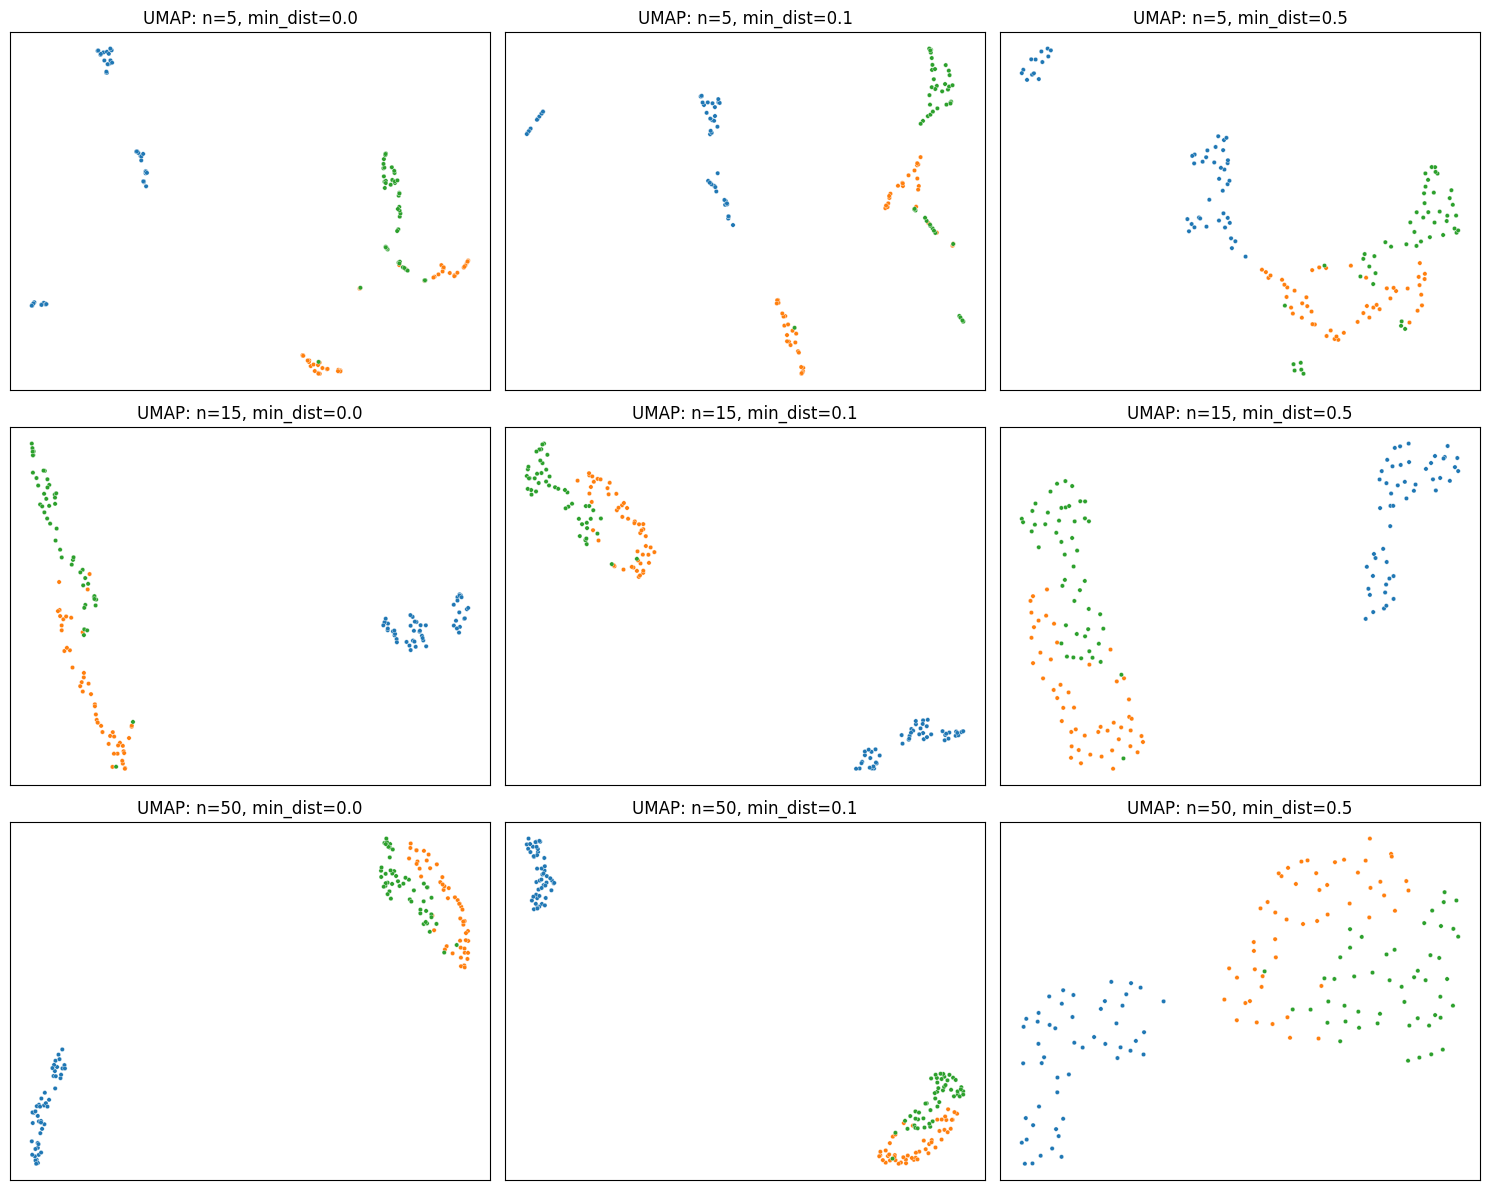

In [26]:
umap_neighbors = [5, 15, 50]
umap_min_dists = [0.0, 0.1, 0.5]

fig, axes = plt.subplots(len(umap_neighbors), len(umap_min_dists), figsize=(5*len(umap_min_dists), 4*len(umap_neighbors)))

for i, n_neighbors in enumerate(umap_neighbors):
    for j, min_dist in enumerate(umap_min_dists):
        X_emb = run_umap(X_iris_scaled, random_state=42, n_neighbors=n_neighbors, min_dist=min_dist)
        ax = axes[i, j]
        sns.scatterplot(x=X_emb[:, 0], y=X_emb[:, 1], hue=y_iris, palette="tab10", s=10, ax=ax, legend=False)
        ax.set_title(f"UMAP: n={n_neighbors}, min_dist={min_dist}")
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()


Обычно структура UMAP меняется плавнее, кластеры остаются узнаваемыми при разумном диапазоне параметров.

*Задача* Аналогично нужно сделать по одной строке графиков для TriMAP, PaCMAP, PHATE с варьированием ключевого параметра (количество соседей или похожий гиперпараметр) и показать, насколько устойчив рисунок.



f:\Education\1course\2trim\Clasterization\venv\lib\site-packages\graphtools\graphs.py:803: RuntimeWarning: Detected zero distance between samples 101 and 142. Consider removing duplicates to avoid errors in downstream processing.
  warnings.warn(


    SGD-MDS may not have converged: stress changed by 1.4% in final iterations. Consider increasing n_iter or adjusting learning_rate.


f:\Education\1course\2trim\Clasterization\venv\lib\site-packages\graphtools\graphs.py:803: RuntimeWarning: Detected zero distance between samples 101 and 142. Consider removing duplicates to avoid errors in downstream processing.
  warnings.warn(


    SGD-MDS may not have converged: stress changed by -1.4% in final iterations. Consider increasing n_iter or adjusting learning_rate.


f:\Education\1course\2trim\Clasterization\venv\lib\site-packages\graphtools\graphs.py:803: RuntimeWarning: Detected zero distance between samples 101 and 142. Consider removing duplicates to avoid errors in downstream processing.
  warnings.warn(


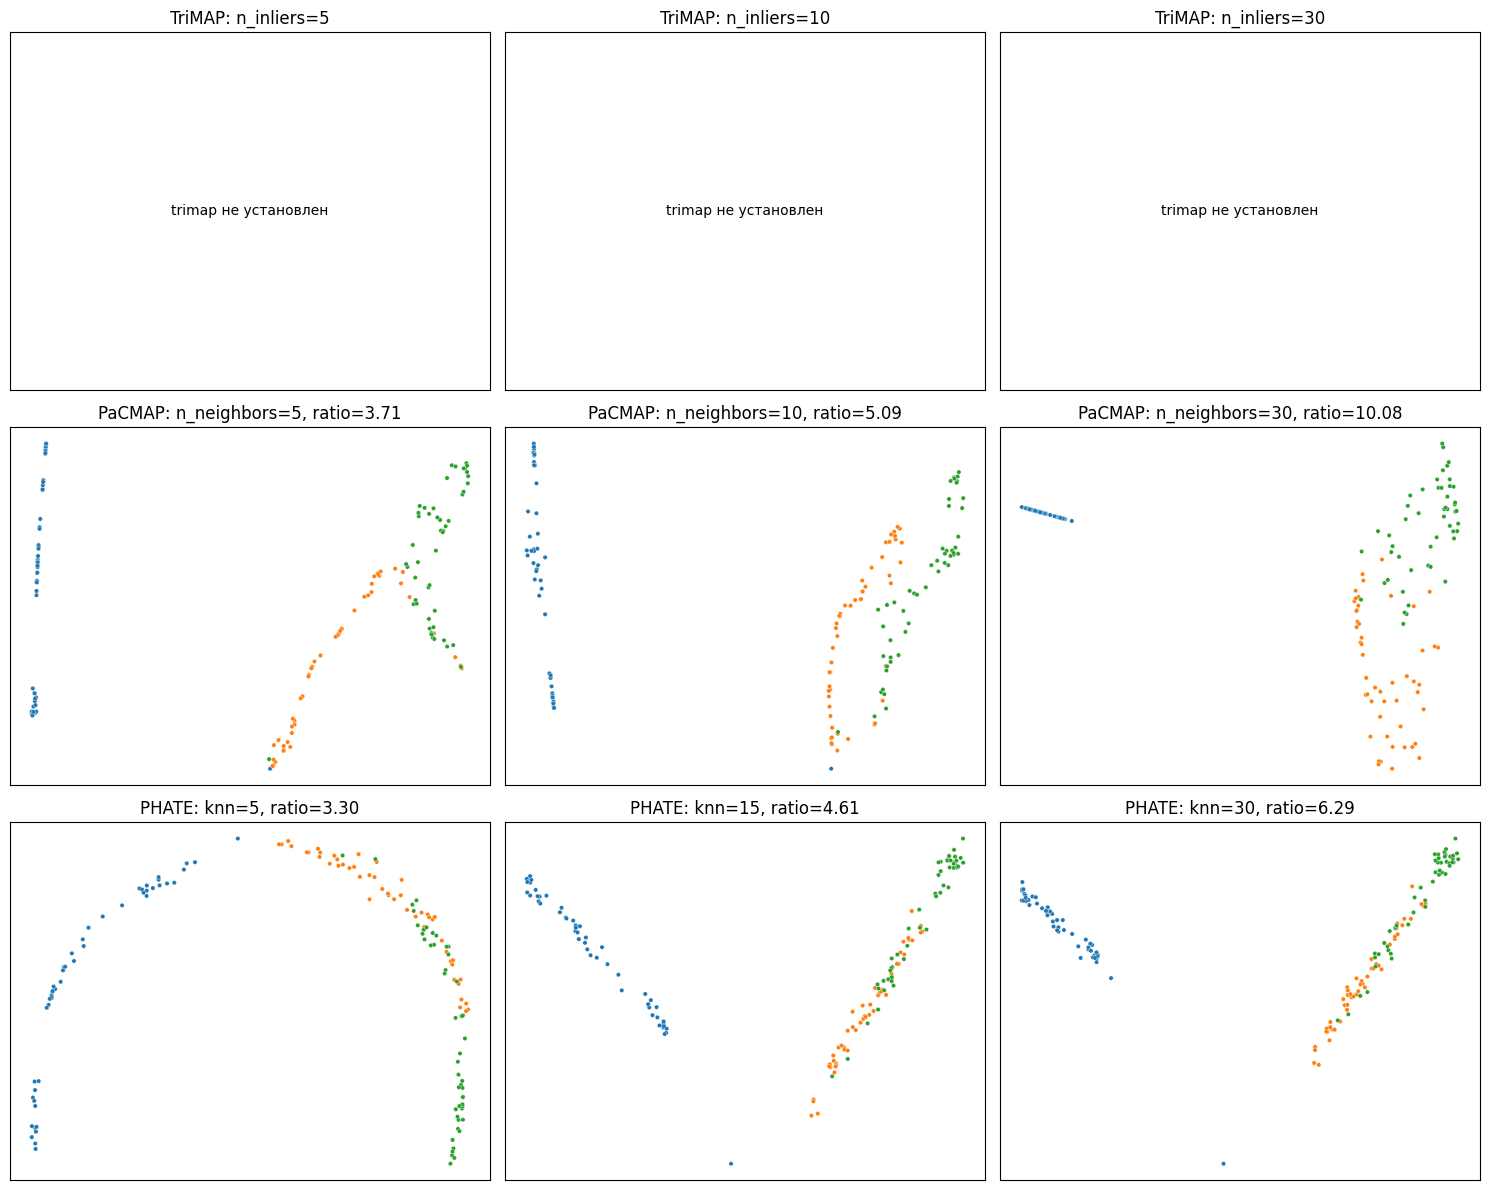

In [27]:
stability_specs = [
    ("TriMAP", run_trimap, "n_inliers", [5, 10, 30]),
    ("PaCMAP", run_pacmap, "n_neighbors", [5, 10, 30]),
    ("PHATE", run_phate, "knn", [5, 15, 30]),
]

fig, axes = plt.subplots(len(stability_specs), 3, figsize=(15, 12))

for i, (name, func, param_name, values) in enumerate(stability_specs):
    for j, value in enumerate(values):
        ax = axes[i, j]
        try:
            X_emb = func(X_iris_scaled, random_state=42, **{param_name: value})
            sns.scatterplot(x=X_emb[:, 0], y=X_emb[:, 1], hue=y_iris, palette="tab10", s=10, ax=ax, legend=False)
            same, diff, ratio = separation_score(X_emb, y_iris)
            ax.set_title(f"{name}: {param_name}={value}, ratio={ratio:.2f}")
        except Exception as err:
            ax.text(0.5, 0.5, str(err), ha="center", va="center", wrap=True)
            ax.set_title(f"{name}: {param_name}={value}")
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()


| Метод  | Скорость на больших данных                   | Локальное разделение              | Глобальная структура                            | Чувствительность к параметрам                         | Комментарий                                        |
| ------ | -------------------------------------------- | --------------------------------- | ----------------------------------------------- | ----------------------------------------------------- | -------------------------------------------------- |
| t‑SNE  | Низкая l                    | Отличное                   | Слабая                                   | Высокая (perplexity, lr, random_state) aicompetence+2 | Хорошо для локальных кластеров, тяжёлый тюнинг     |
| UMAP   | Высокая l                   | Очень хорошее   | Лучшая, чем у t‑SNE           | Ниже, чем у t‑SNE aicompetence+2                      | Хороший баланс локал/глобал, удобен в практике     |
| TriMAP | Средняя                              | Хорошее                   | Сильный упор на глобальную структуру    | Умеренная                                     | Лучше показывает относительное положение кластеров |
| PaCMAP | Средняя                               | Отличное                   | Хорошее                                  | Умеренная                                      | Часто даёт чёткие кластеры и форму многобразия     |
| PHATE  | Средняя/низкая (зависит от размера)   | Хорошее        | Очень хорошее, особенно для траекторий   | Умеренная                          | Сильный метод для непрерывных переходов            |

# Варианты препроцессинга
*Задача* — явно сравнить, как UMAP и t‑SNE реагируют на разные варианты нормировки и отбора признаков.

## Определяем три сценария
Без масштабирования (сырой набор признаков).

StandardScaler (z‑нормировка).

MinMaxScaler + отбор признаков по дисперсии (эмуляция feature selection).

Задание. Проделать все три сценария. Обучить все модели при разных сценария кластеризации. 
Нужно в результате:
1. описать, какие признаки были отброшены и почему это может влиять на качество кластеризации во вложенном пространстве.
1. сравнить вычислительное время и сделать вывод о масштабируемости методов
1. изменить гиперпараметры (perplexity, n_neighbors, min_dist) и исследовать совместное влияние гиперпараметров и препроцессинга на структуру кластеров.


Отброшенные признаки: [np.str_('sepal width (cm)')]
Оставленные признаки: [np.str_('sepal length (cm)'), np.str_('petal length (cm)'), np.str_('petal width (cm)')]
Причина: после MinMaxScaler их дисперсия ниже порога 0.05, поэтому они слабее различают наблюдения в выбранном масштабе.


f:\Education\1course\2trim\Clasterization\venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
f:\Education\1course\2trim\Clasterization\venv\lib\site-packages\graphtools\graphs.py:803: RuntimeWarning: Detected zero distance between samples 101 and 142. Consider removing duplicates to avoid errors in downstream processing.
  warnings.warn(
f:\Education\1course\2trim\Clasterization\venv\lib\site-packages\phate\phate.py:919: RuntimeWarning: Graph is disconnected with 2 connected components. This may indicate that your knn parameter (currently 15) is too small, or that your data contains distinct clusters. PHATE may not accurately represent relationships between disconnected components.
  warnings.warn(


    SGD-MDS may not have converged: stress changed by -2.1% in final iterations. Consider increasing n_iter or adjusting learning_rate.


f:\Education\1course\2trim\Clasterization\venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
f:\Education\1course\2trim\Clasterization\venv\lib\site-packages\graphtools\graphs.py:803: RuntimeWarning: Detected zero distance between samples 101 and 142. Consider removing duplicates to avoid errors in downstream processing.
  warnings.warn(


    SGD-MDS may not have converged: stress changed by -1.4% in final iterations. Consider increasing n_iter or adjusting learning_rate.


f:\Education\1course\2trim\Clasterization\venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
f:\Education\1course\2trim\Clasterization\venv\lib\site-packages\graphtools\graphs.py:803: RuntimeWarning: Detected zero distance between samples 4 and 49, 11 and 30, 38 and 42, 53 and 89, 101 and 142. Consider removing duplicates to avoid errors in downstream processing.
  warnings.warn(
f:\Education\1course\2trim\Clasterization\venv\lib\site-packages\phate\phate.py:919: RuntimeWarning: Graph is disconnected with 2 connected components. This may indicate that your knn parameter (currently 15) is too small, or that your data contains distinct clusters. PHATE may not accurately represent relationships between disconnected components.
  warnings.warn(


    SGD-MDS may not have converged: stress changed by -3.2% in final iterations. Consider increasing n_iter or adjusting learning_rate.
preprocessing method  time_sec     ratio               status
   minmax_var TriMAP  0.000006       NaN trimap не установлен
   minmax_var PaCMAP  0.087931  5.851375                   ok
   minmax_var  PHATE  0.172244 30.165403                   ok
   minmax_var   UMAP  0.225250  7.295004                   ok
   minmax_var  t-SNE  0.505616  9.476589                   ok
          raw TriMAP  0.000007       NaN trimap не установлен
          raw PaCMAP  0.085207  5.970613                   ok
          raw  PHATE  0.188620 23.599766                   ok
          raw   UMAP  0.232342  7.505951                   ok
          raw  t-SNE  0.431633  9.775370                   ok
     standard TriMAP  0.000011       NaN trimap не установлен
     standard PaCMAP  0.081459  5.093235                   ok
     standard  PHATE  0.175082  4.610111                  

f:\Education\1course\2trim\Clasterization\venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
f:\Education\1course\2trim\Clasterization\venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
f:\Education\1course\2trim\Clasterization\venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
f:\Education\1course\2trim\Clasterization\venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
f:\Education\1course\2trim\Clasterization\venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
f:\Education\1course\2trim\Clasterization\ven

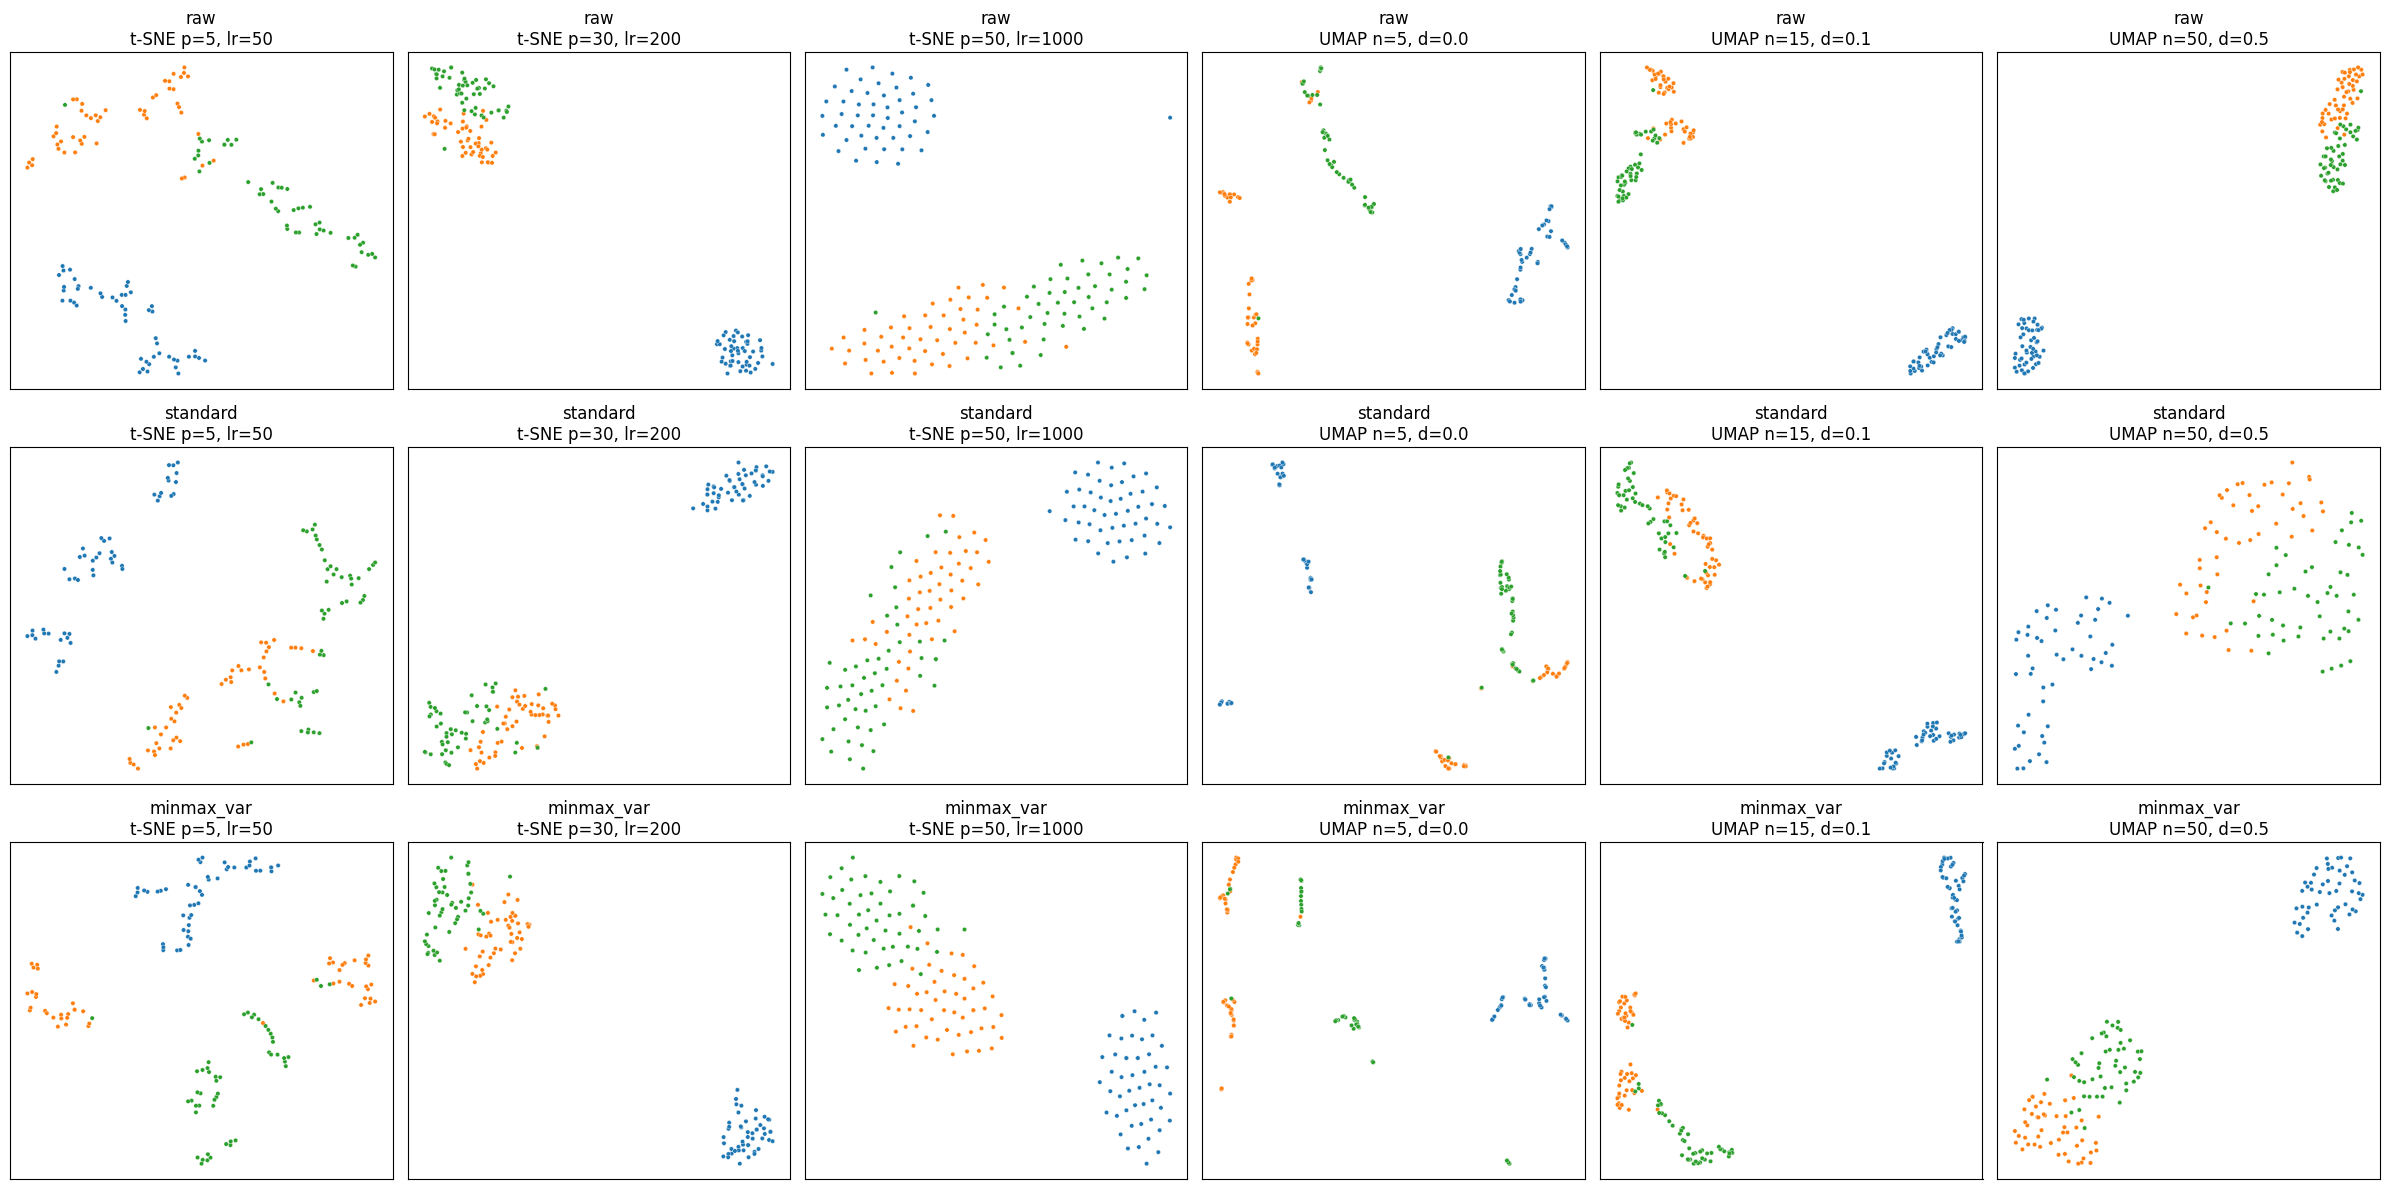

preprocessing method  perplexity  learning_rate     ratio  n_neighbors  min_dist
          raw   UMAP         NaN            NaN 10.582856         50.0       0.5
          raw  t-SNE        30.0          200.0  9.775370          NaN       NaN
   minmax_var  t-SNE        30.0          200.0  9.476589          NaN       NaN
          raw   UMAP         NaN            NaN  7.505951         15.0       0.1
   minmax_var   UMAP         NaN            NaN  7.295004         15.0       0.1
   minmax_var   UMAP         NaN            NaN  6.622265         50.0       0.5
     standard  t-SNE        30.0          200.0  6.475139          NaN       NaN
     standard   UMAP         NaN            NaN  6.411327         15.0       0.1
   minmax_var  t-SNE        50.0         1000.0  4.608487          NaN       NaN
          raw   UMAP         NaN            NaN  4.413306          5.0       0.0
          raw  t-SNE        50.0         1000.0  3.554570          NaN       NaN
     standard  t-SNE        

In [28]:
X_minmax = MinMaxScaler().fit_transform(X_iris)
selector = VarianceThreshold(threshold=0.05)
X_minmax_selected = selector.fit_transform(X_minmax)
selected_features = np.array(feature_names_iris)[selector.get_support()]
dropped_features = np.array(feature_names_iris)[~selector.get_support()]

preprocessing_scenarios = [
    ("raw", X_iris),
    ("standard", X_iris_scaled),
    ("minmax_var", X_minmax_selected),
]

print("Отброшенные признаки:", list(dropped_features))
print("Оставленные признаки:", list(selected_features))
print("Причина: после MinMaxScaler их дисперсия ниже порога 0.05, поэтому они слабее различают наблюдения в выбранном масштабе.")

benchmark_rows = []

for prep_name, X_prep in preprocessing_scenarios:
    for method_name, func, params in methods:
        started = time.perf_counter()
        try:
            X_emb = func(X_prep, random_state=42, **params)
            same, diff, ratio = separation_score(X_emb, y_iris)
            status = "ok"
        except Exception as err:
            same, diff, ratio = np.nan, np.nan, np.nan
            status = str(err)
        elapsed = time.perf_counter() - started
        benchmark_rows.append({
            "preprocessing": prep_name,
            "method": method_name,
            "time_sec": elapsed,
            "same": same,
            "diff": diff,
            "ratio": ratio,
            "status": status,
        })

benchmark = pd.DataFrame(benchmark_rows)
print(benchmark[["preprocessing", "method", "time_sec", "ratio", "status"]].sort_values(["preprocessing", "time_sec"]).to_string(index=False))

param_rows = []
tsne_grid = [
    {"perplexity": 5, "learning_rate": 50},
    {"perplexity": 30, "learning_rate": 200},
    {"perplexity": 50, "learning_rate": 1000},
]
umap_grid = [
    {"n_neighbors": 5, "min_dist": 0.0},
    {"n_neighbors": 15, "min_dist": 0.1},
    {"n_neighbors": 50, "min_dist": 0.5},
]

fig, axes = plt.subplots(len(preprocessing_scenarios), 6, figsize=(24, 12))

for i, (prep_name, X_prep) in enumerate(preprocessing_scenarios):
    for j, params in enumerate(tsne_grid):
        X_emb = run_tsne(X_prep, random_state=42, **params)
        same, diff, ratio = separation_score(X_emb, y_iris)
        param_rows.append({"preprocessing": prep_name, "method": "t-SNE", **params, "ratio": ratio})
        ax = axes[i, j]
        sns.scatterplot(x=X_emb[:, 0], y=X_emb[:, 1], hue=y_iris, palette="tab10", s=10, ax=ax, legend=False)
        ax.set_title(f"{prep_name}\nt-SNE p={params['perplexity']}, lr={params['learning_rate']}")
        ax.set_xticks([])
        ax.set_yticks([])
    for j, params in enumerate(umap_grid, start=3):
        X_emb = run_umap(X_prep, random_state=42, **params)
        same, diff, ratio = separation_score(X_emb, y_iris)
        param_rows.append({"preprocessing": prep_name, "method": "UMAP", **params, "ratio": ratio})
        ax = axes[i, j]
        sns.scatterplot(x=X_emb[:, 0], y=X_emb[:, 1], hue=y_iris, palette="tab10", s=10, ax=ax, legend=False)
        ax.set_title(f"{prep_name}\nUMAP n={params['n_neighbors']}, d={params['min_dist']}")
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()

param_results = pd.DataFrame(param_rows)
print(param_results.sort_values("ratio", ascending=False).to_string(index=False))